# 🔮 Part 1: The Predictive AI World

## From Predictive to Generative AI — UbuCon 2026 Workshop

---

### What You'll Learn
- The classic ML pipeline: **Load → Clean → Explore → Train → Predict**
- How traditional machine learning finds patterns in structured data
- The fundamental limitation: **Predictive AI can only output known categories**

### The Challenge
> *"You're a detective in 1912. You have passenger records from the Titanic. Can you predict who survived — using only numbers?"*

### Why This Matters
Before we can appreciate what Generative AI unlocks, we need to understand what came before it — and where it hits a wall.

---

## Step 1: Setup — Install & Import Libraries

Every ML project starts with the right tools. On Ubuntu, these install cleanly via pip.

In [2]:
# !pip install -q pandas scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Cleaner plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries loaded — ready to predict!')

✅ All libraries loaded — ready to predict!


## Step 2: Load the Data

The Titanic dataset is the "Hello World" of machine learning with 891 passengers, 12 features each.

| Column | Description |
|--------|-------------|
| Survived | 0 = Died, 1 = Survived (our **target**) |
| Pclass | Ticket class: 1st, 2nd, 3rd |
| Sex | male / female |
| Age | Age in years |
| SibSp | # siblings/spouses aboard |
| Parch | # parents/children aboard |
| Fare | Ticket price in 1912 British pounds |

In [3]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'📊 Dataset: {df.shape[0]} passengers × {df.shape[1]} features')
print(f'🎯 Survival rate: {df["Survived"].mean():.1%} ({df["Survived"].sum()}/{df.shape[0]})')
print()
df.head()

📊 Dataset: 891 passengers × 12 features
🎯 Survival rate: 38.4% (342/891)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Explore : Understand the Data Before Modeling

> *"You can't predict what you don't understand."*

Let's visualize the key survival patterns.

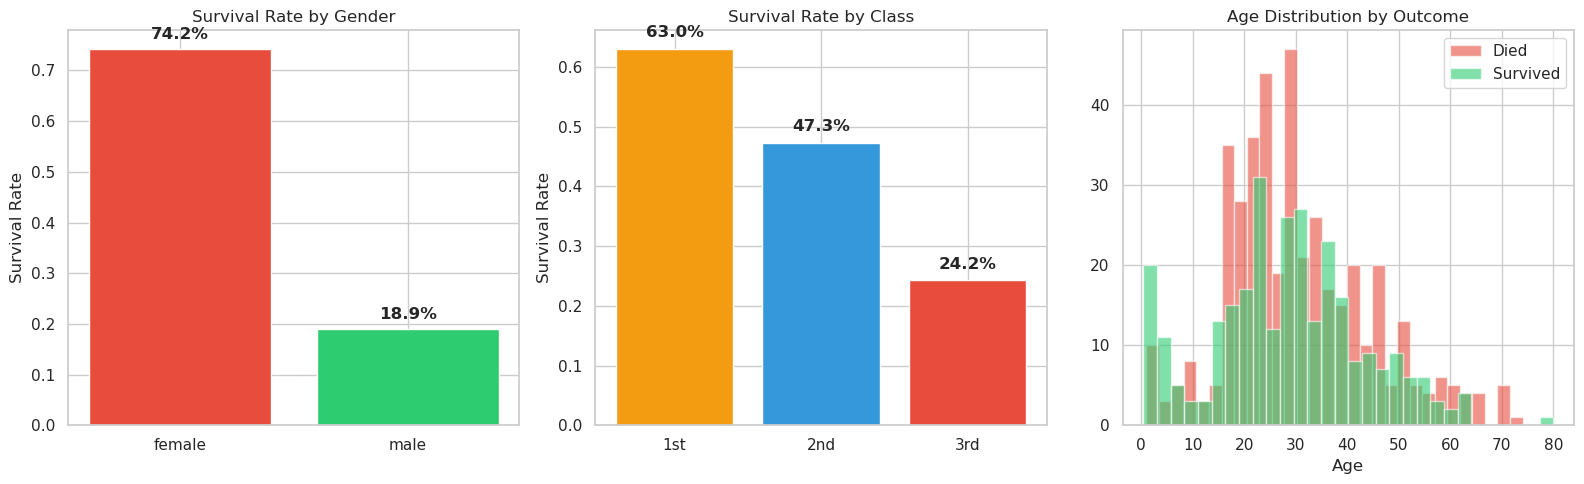

📌 Key patterns: Women survived more. Higher class = better odds. Children had priority.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Survival by Gender
survival_by_sex = df.groupby('Sex')['Survived'].mean()
axes[0].bar(survival_by_sex.index, survival_by_sex.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Survival by Class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
colors = ['#f39c12', '#3498db', '#e74c3c']
axes[1].bar(['1st', '2nd', '3rd'], survival_by_class.values, color=colors)
axes[1].set_title('Survival Rate by Class')
axes[1].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Age Distribution by Survival
df[df['Survived'] == 0]['Age'].hist(ax=axes[2], bins=30, alpha=0.6,
                                     color='#e74c3c', label='Died')
df[df['Survived'] == 1]['Age'].hist(ax=axes[2], bins=30, alpha=0.6,
                                     color='#2ecc71', label='Survived')
axes[2].set_title('Age Distribution by Outcome')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

print('📌 Key patterns: Women survived more. Higher class = better odds. Children had priority.')

These charts provide a clear breakdown of the factors that influenced a passenger's chance of survival on the Titanic. Based on the visualizations, here is an explanation of the key findings:

### 1. Gender: The Strongest Predictor
The first chart shows a massive disparity in survival rates between genders.
* **Females:** Had a **74.2%** survival rate. This reflects the "women and children first" maritime protocol.
* **Males:** Had only an **18.9%** survival rate. Men were significantly less likely to be given a spot on the limited number of lifeboats.

### 2. Socioeconomic Status (Passenger Class)
The second chart illustrates that wealth and social standing played a major role in survival.
* **1st Class:** Nearly **63%** survived. These passengers had better access to the top decks and lifeboats.
* **2nd Class:** Roughly **47.3%** survived, showing a moderate chance.
* **3rd Class:** Only **24.2%** survived. This group faced the greatest hurdles, including being located deeper in the ship and further from the lifeboats.

### 3. Age Distribution by Outcome
The histogram on the right compares the ages of those who died (red) versus those who survived (green).
* **Infants/Children:** You can see a small green peak at the very left (ages 0–10), indicating that young children were prioritized for survival.
* **Young Adults (20–40):** This was the largest group on the ship. The red bars are significantly higher than the green bars here, showing that a high number of adults in their prime did not survive.
* **Elderly:** Survival becomes very rare as age increases, with almost no green bars visible for passengers over age 60 (with one notable exception near age 80).

In [5]:
# Missing data — a reality of real-world datasets
missing = df.isnull().sum()
print('🔍 Missing values:')
print(missing[missing > 0])
print(f'\n⚠️  Age is missing for {missing["Age"]} passengers — we need to handle this.')

🔍 Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64

⚠️  Age is missing for 177 passengers — we need to handle this.


## Step 4: Clean : Prepare Data for the Algorithm

Machine learning algorithms need **numbers, not text**. No missing values allowed.

This is the tedious but critical part of traditional ML.

In [6]:
# Select features and create a clean copy
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
clean = df[features + ['Survived']].copy()

# Fill missing ages with median
clean['Age'] = clean['Age'].fillna(clean['Age'].median())

# Fill missing fares with median
clean['Fare'] = clean['Fare'].fillna(clean['Fare'].median())

# Convert text to numbers: male=1, female=0
clean['Sex'] = clean['Sex'].map({'male': 1, 'female': 0})

print('✅ Data cleaned!')
print(f'   Shape: {clean.shape}')
print(f'   Missing values: {clean.isnull().sum().sum()}')
clean.head()

✅ Data cleaned!
   Shape: (891, 7)
   Missing values: 0


,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,3,1,22.0,1,0,7.2500,0
1,1,0,38.0,1,0,71.2833,1
2,3,0,26.0,0,0,7.9250,1
3,1,0,35.0,1,0,53.1000,1
4,3,1,35.0,0,0,8.0500,0


## Step 5: Train : Teach the Algorithm to Find Patterns

We split the data:
- **80% Training**: The algorithm learns patterns
- **20% Testing**: We check if it actually learned (not just memorized)

Our algorithm: **Logistic Regression** a simple, interpretable classifier.

In [7]:
# Separate features (X) from target (y)
X = clean.drop('Survived', axis=1)
y = clean['Survived']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'🎓 Training: {X_train.shape[0]} passengers')
print(f'🧪 Testing:  {X_test.shape[0]} passengers')

# Train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f'\n📈 Training accuracy: {train_acc:.1%}')
print(f'📈 Testing accuracy:  {test_acc:.1%}')
print(f'\n{classification_report(y_test, model.predict(X_test), target_names=["Died", "Survived"])}')

🎓 Training: 712 passengers
🧪 Testing:  179 passengers

📈 Training accuracy: 79.2%
📈 Testing accuracy:  80.4%

              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



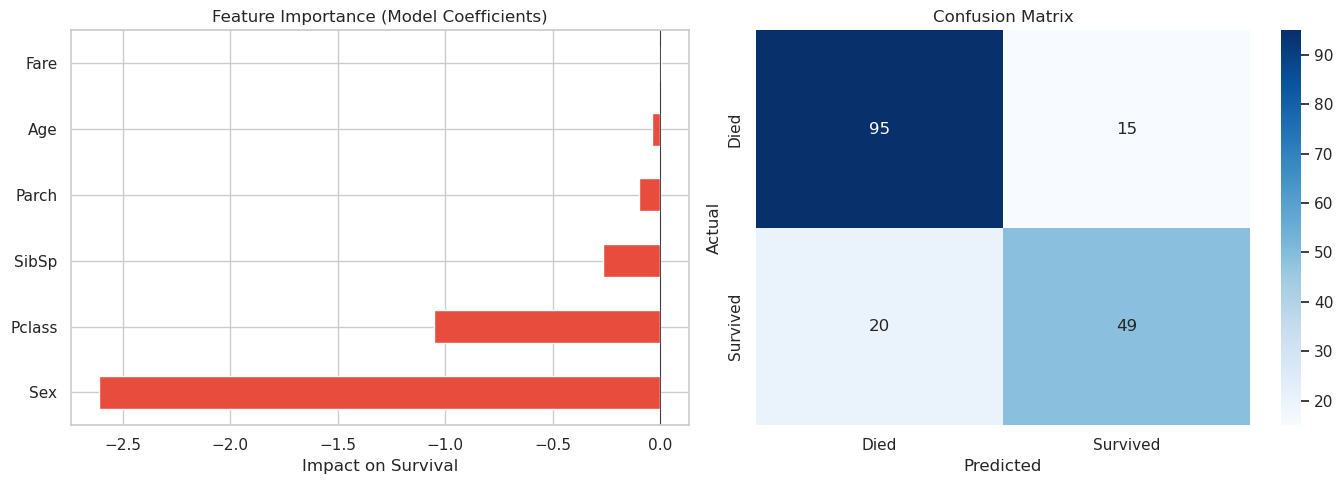

📌 Sex is the strongest predictor — being female dramatically increases survival odds.


In [8]:
# Visualize: What did the model learn?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importance = pd.Series(model.coef_[0], index=X.columns).sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in importance]
importance.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Feature Importance (Model Coefficients)')
axes[0].set_xlabel('Impact on Survival')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Confusion matrix
cm = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('📌 Sex is the strongest predictor — being female dramatically increases survival odds.')

## Step 6: Predict : Use the Model on New Passengers

Let's create fictional passengers and see what our model predicts.

In [9]:
new_passengers = pd.DataFrame({
    'Pclass': [1, 3, 2, 1, 3],
    'Sex':    [0, 1, 0, 1, 0],  # 0=Female, 1=Male
    'Age':    [25, 30, 45, 35, 8],
    'SibSp':  [0, 1, 2, 0, 1],
    'Parch':  [0, 2, 1, 0, 1],
    'Fare':   [100, 15, 50, 200, 20]
})

names = [
    'Lady Margaret (1st Class Woman, 25)',
    'John Smith (3rd Class Man, 30)',
    'Mrs. Brown (2nd Class Woman, 45)',
    'Lord Ashton (1st Class Man, 35)',
    'Little Mary (3rd Class Girl, 8)'
]

predictions = model.predict(new_passengers)
probabilities = model.predict_proba(new_passengers)[:, 1]

print('🔮 PREDICTIONS FOR NEW PASSENGERS')
print('=' * 60)
for name, pred, prob in zip(names, predictions, probabilities):
    outcome = '✅ SURVIVED' if pred == 1 else '💀 DIED'
    print(f'{name}')
    print(f'   → {outcome}  (survival probability: {prob:.1%})')
    print()

🔮 PREDICTIONS FOR NEW PASSENGERS
Lady Margaret (1st Class Woman, 25)
   → ✅ SURVIVED  (survival probability: 95.2%)

John Smith (3rd Class Man, 30)
   → 💀 DIED  (survival probability: 6.5%)

Mrs. Brown (2nd Class Woman, 45)
   → ✅ SURVIVED  (survival probability: 59.0%)

Lord Ashton (1st Class Man, 35)
   → ✅ SURVIVED  (survival probability: 57.6%)

Little Mary (3rd Class Girl, 8)
   → ✅ SURVIVED  (survival probability: 71.2%)



## ⚠️ The Critical Limitation of Predictive AI

### What we accomplished:
- ✅ Built a model that predicts survival with ~80% accuracy
- ✅ Followed the classic pipeline: Load → Clean → Explore → Train → Predict
- ✅ Used historical data to find patterns

### What this model **CANNOT** do:
- ❌ **Explain WHY** someone survived in natural language
- ❌ **Generate** a story about a passenger's experience
- ❌ **Answer questions** like "What was life like in 3rd class?"
- ❌ **Create** anything new, it only outputs **0 or 1**
- ❌ **Adapt** to questions it wasn't trained for

### The output is always:
```
0  →  Died
1  →  Survived
```

**That's it. Nothing more. No creativity. No explanation. No conversation.**


### 🚀 What if we could just *ask* the AI in plain English?

**→ Open Notebook 2 to enter the Generative AI world!**